In [1]:
!pip install pmlb

*Import necessary libraries*

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay

*To keep the output clean*

In [4]:
import warnings
warnings.filterwarnings('ignore')

# LOADING AND PREPARATION OF DATASET

In [21]:
auto_data = fetch_openml(name='autoPrice', version=1, as_frame=True, parser='auto')
print(auto_data)

{'data':      symboling  normalized-losses  wheel-base  length  width  height  \
0            2                164        99.8   176.6   66.2    54.3   
1            2                164        99.4   176.6   66.4    54.3   
2            1                158       105.8   192.7   71.4    55.7   
3            1                158       105.8   192.7   71.4    55.9   
4            2                192       101.2   176.8   64.8    54.3   
..         ...                ...         ...     ...    ...     ...   
154         -1                 95       109.1   188.8   68.9    55.5   
155         -1                 95       109.1   188.8   68.8    55.5   
156         -1                 95       109.1   188.8   68.9    55.5   
157         -1                 95       109.1   188.8   68.9    55.5   
158         -1                 95       109.1   188.8   68.9    55.5   

     curb-weight  engine-size  bore  stroke  compression-ratio  horsepower  \
0           2337          109  3.19    3.40     

*For classification, my target is the 'symboling' risk rating category*

In [22]:
y = auto_data.data['symboling'].astype(int)

*My features are everything else... I drop 'symboling' so the model doesn`t cheat*

In [23]:
X_raw = auto_data.data.drop('symboling', axis = 1)

Converting text to numbers and fullfil missing values with 0

In [24]:
X = pd.get_dummies(X_raw, drop_first = True)
X = X.fillna(0)
feature_names = X.columns.tolist()

# TRAIN / TEST SPLIT

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Training the decision tree classifier

In [86]:
dtree = DecisionTreeClassifier(criterion = 'entropy', max_depth = 5, random_state = 42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Classification results

In [87]:
y_pred = dtree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("------Classification Results-----")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Report")
print(classification_report(y_test, y_pred, zero_division = 0))

------Classification Results-----
Overall Accuracy: 68.75%

Detailed Report
              precision    recall  f1-score   support

          -2       1.00      1.00      1.00         1
          -1       1.00      1.00      1.00         3
           0       0.60      0.60      0.60         5
           1       0.62      0.45      0.53        11
           2       0.73      0.89      0.80         9
           3       0.50      0.67      0.57         3

    accuracy                           0.69        32
   macro avg       0.74      0.77      0.75        32
weighted avg       0.69      0.69      0.68        32



# Visualization of decision tree

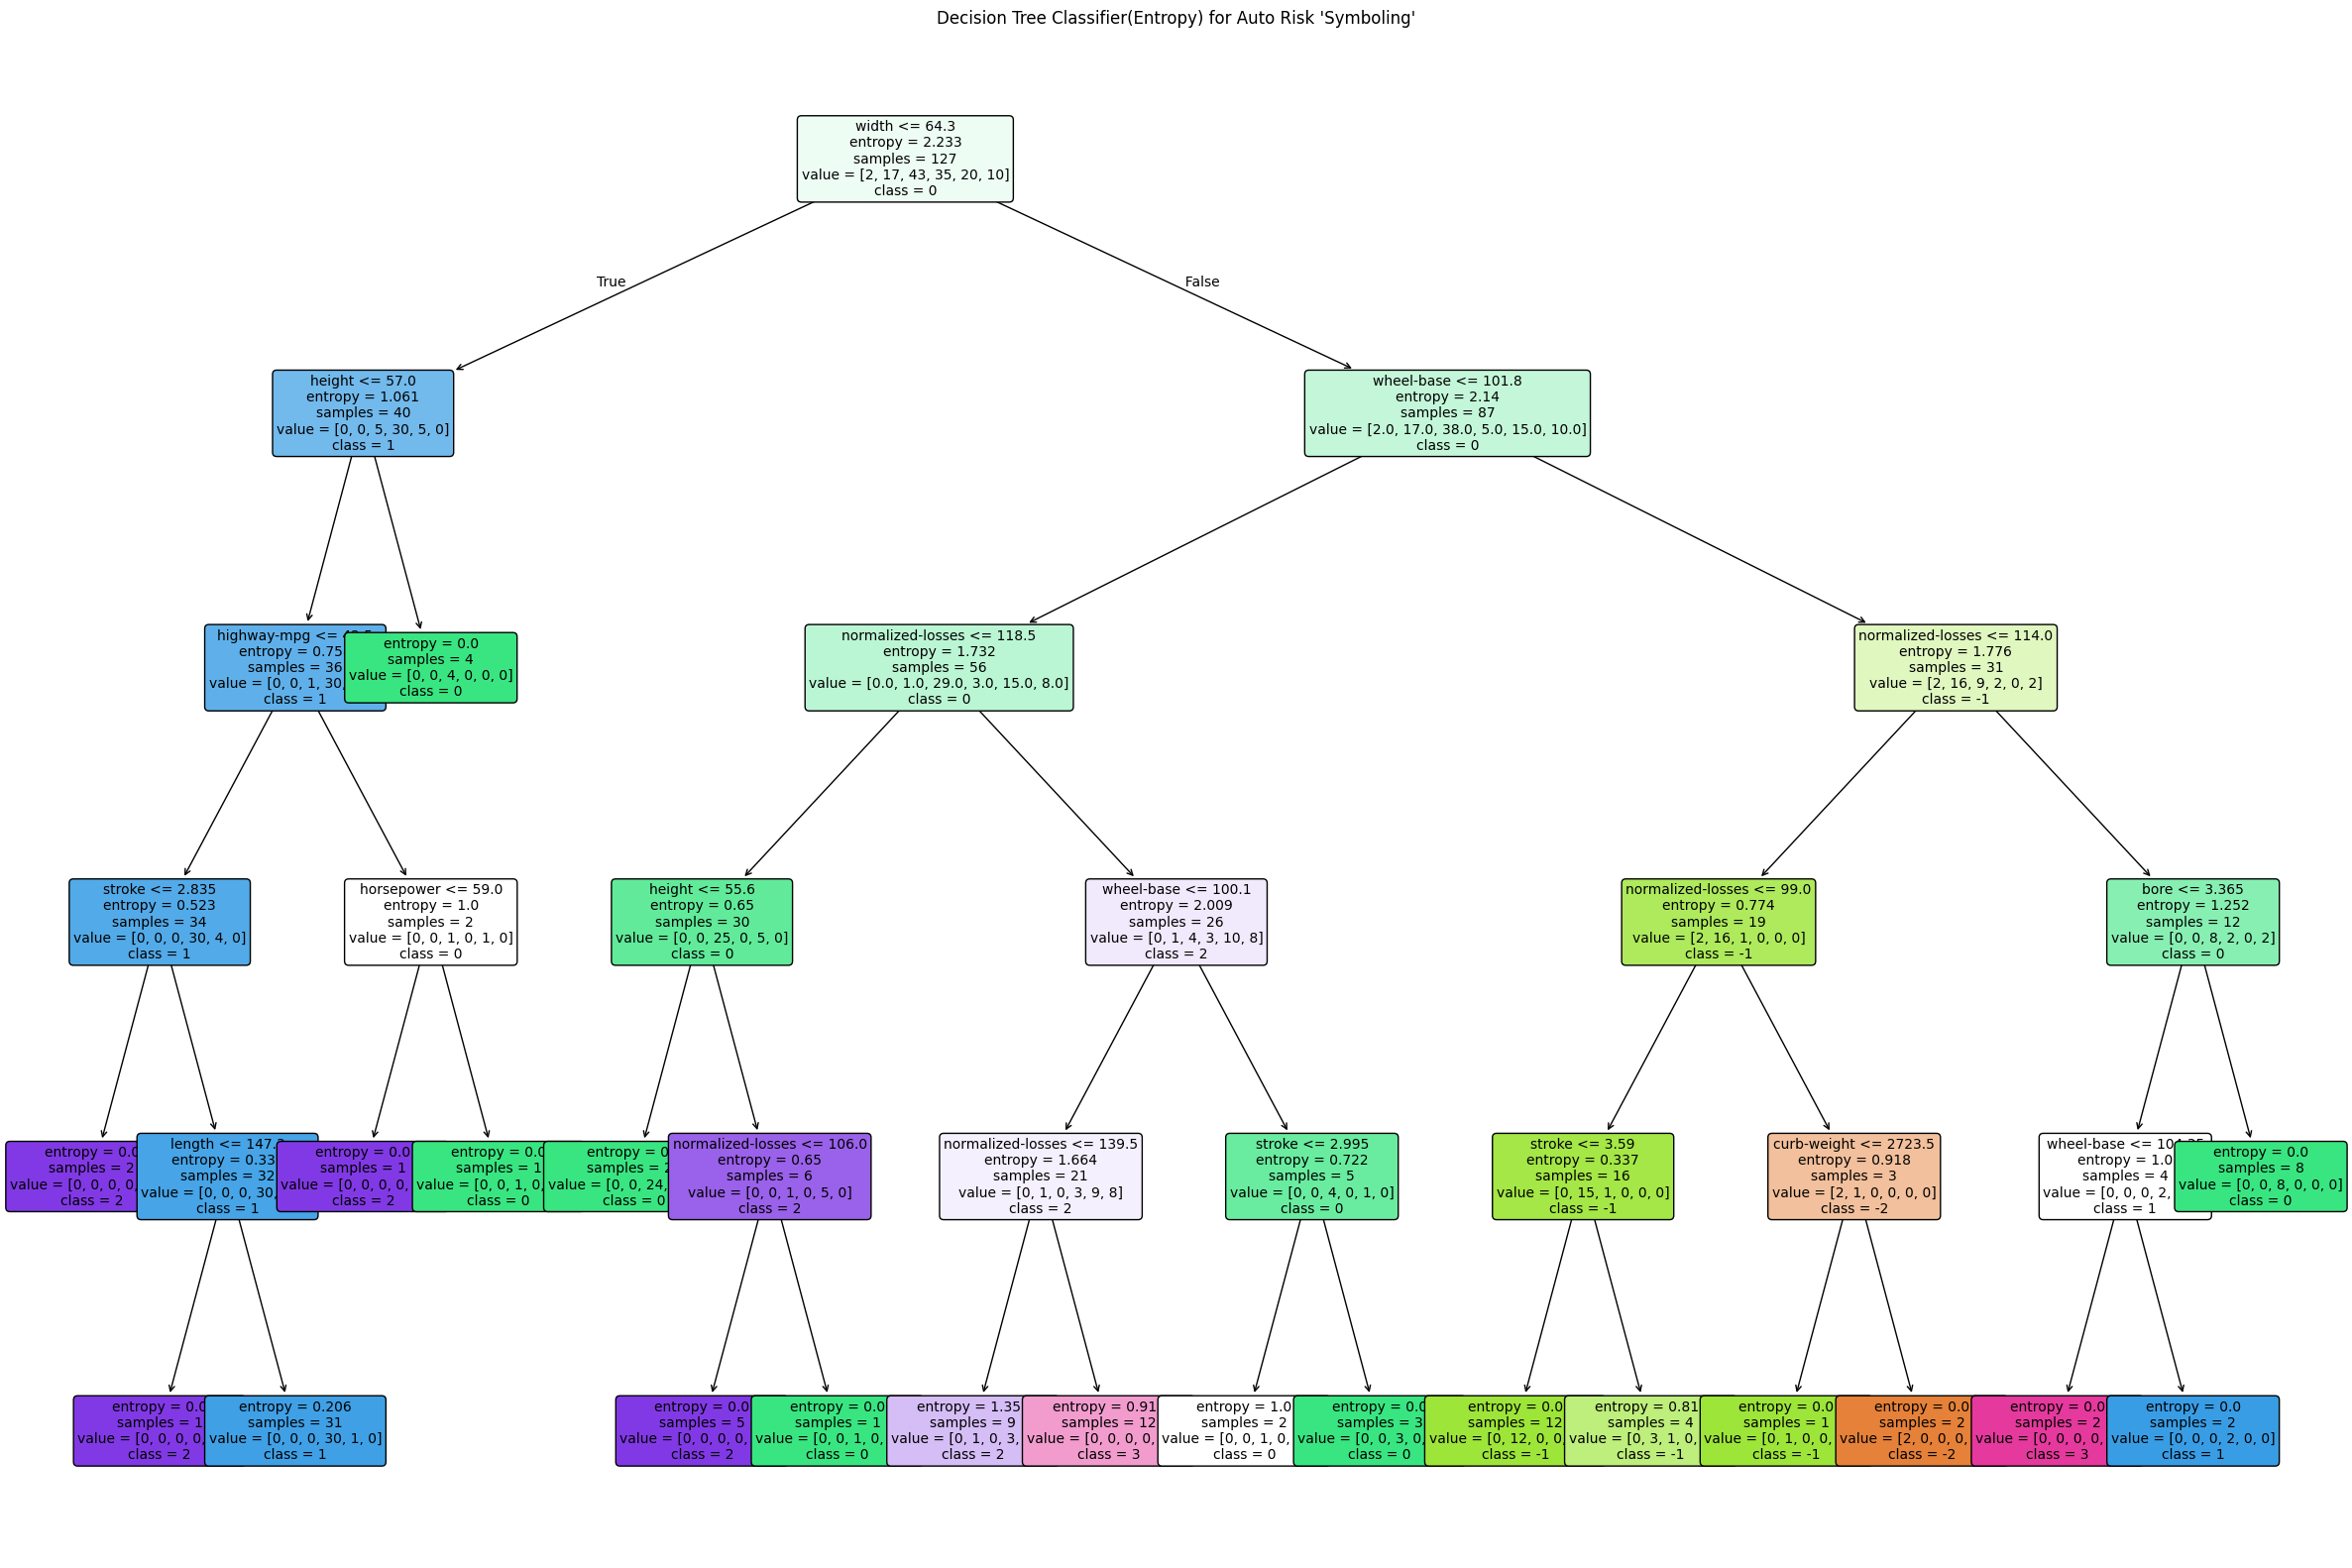

In [88]:
plt.figure(figsize = (30, 20))
plot_tree(dtree, feature_names = feature_names, class_names = [str(c) for c in np.unique(y)], filled = True, rounded = True, fontsize = 10)
plt.title("Decision Tree Classifier(Entropy) for Auto Risk 'Symboling'")
plt.savefig("classification_tree.png")
plt.show()

Let`s try with gini impurity

In [125]:
dtree = DecisionTreeClassifier(criterion = 'gini', max_depth = 4, random_state = 42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [128]:
y_pred = dtree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("------Classification Results-----")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Report:")
print(classification_report(y_test, y_pred, zero_division = 0))

------Classification Results-----
Overall Accuracy: 75.00%

Detailed Report:
              precision    recall  f1-score   support

          -2       1.00      1.00      1.00         1
          -1       1.00      1.00      1.00         3
           0       0.75      0.60      0.67         5
           1       0.70      0.64      0.67        11
           2       0.75      1.00      0.86         9
           3       0.50      0.33      0.40         3

    accuracy                           0.75        32
   macro avg       0.78      0.76      0.77        32
weighted avg       0.74      0.75      0.74        32



# Visualization of decision tree

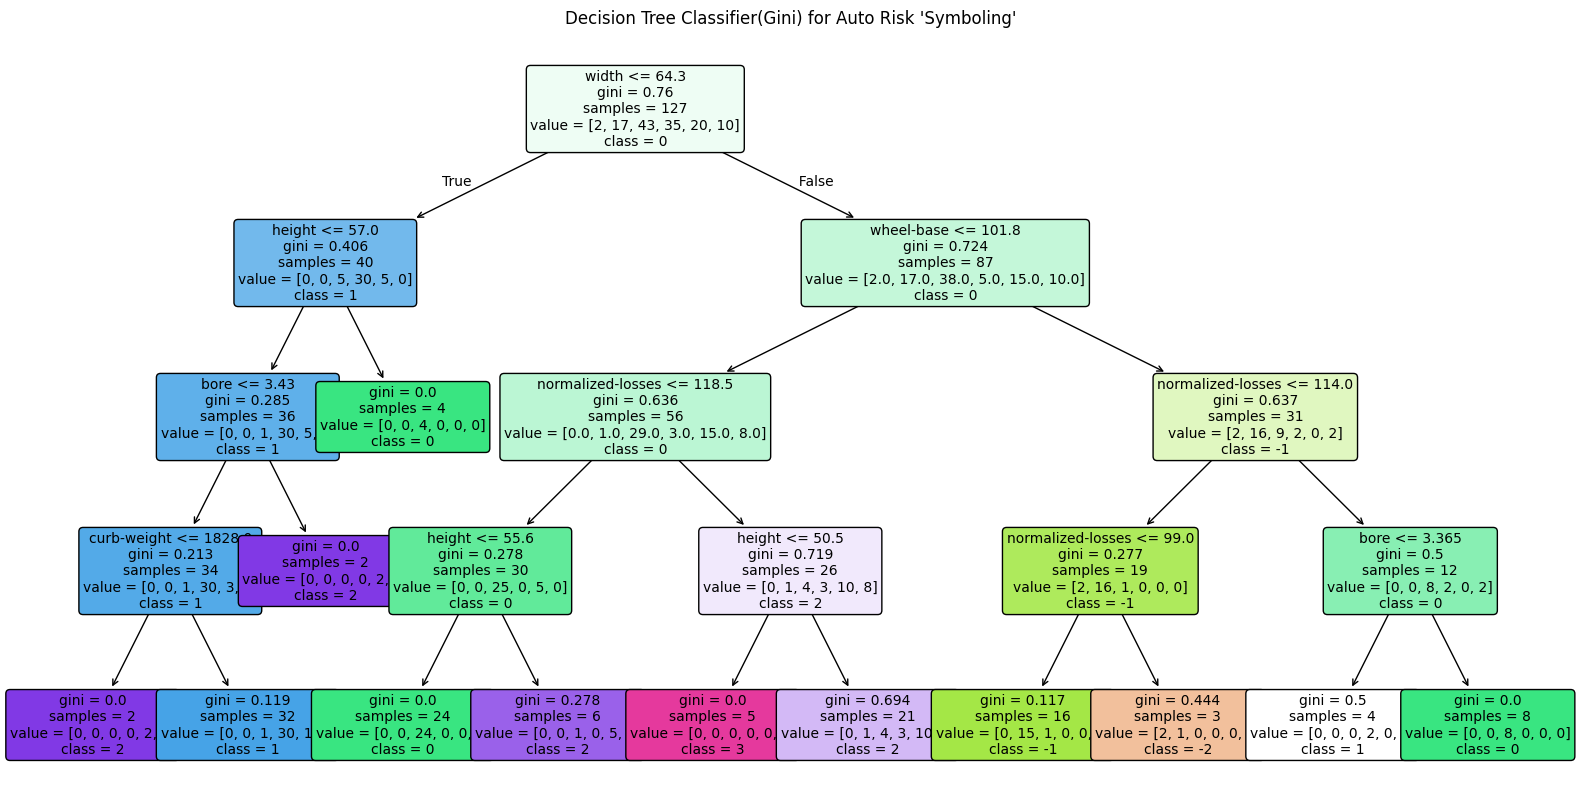

In [130]:
plt.figure(figsize = (20, 10))
plot_tree(dtree, feature_names = feature_names, class_names = [str(c) for c in np.unique(y)], filled = True, rounded = True, fontsize = 10)
plt.title("Decision Tree Classifier(Gini) for Auto Risk 'Symboling'")
plt.savefig("classification_tree.png")
plt.show()

# Feature Importance

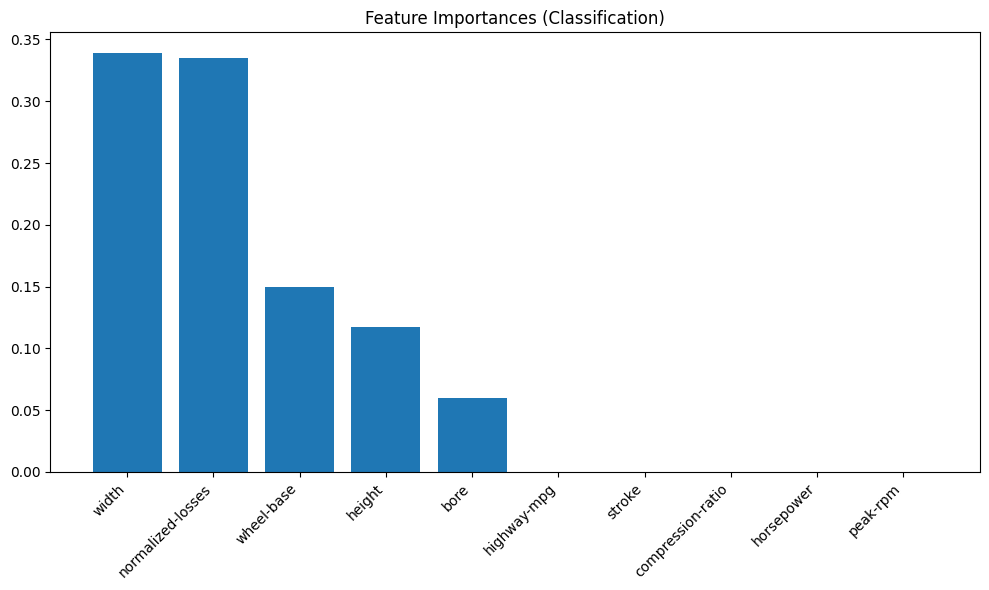

In [33]:
importances = dtree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize = (10, 6))
plt.title("Feature Importances (Classification)")
plt.bar(range(10), importances[indices][:10], align = "center")
plt.xticks(range(10), [feature_names[i] for i in indices][:10], rotation = 45, ha = "right")
plt.tight_layout()
plt.savefig("feature_importance_class.png")
plt.show()

# Partition of feature space (2D)

<Figure size 800x600 with 0 Axes>

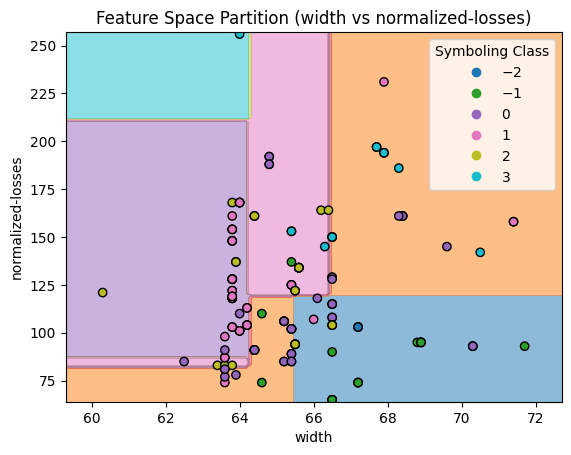

In [34]:
top_feature_1 = feature_names[indices[0]]
top_feature_2 = feature_names[indices[1]]

X_2d = X[[top_feature_1, top_feature_2]]
dtree_2d = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3, random_state = 42)
dtree_2d.fit(X_2d, y)

plt.figure(figsize = (8, 6))
disp = DecisionBoundaryDisplay.from_estimator(dtree_2d, X_2d, response_method = "predict", cmap = "tab10", alpha = 0.5)
scatter = disp.ax_.scatter(X_2d.iloc[:, 0], X_2d.iloc[:, 1], c=y, edgecolor = "k", cmap = "tab10")
plt.legend(*scatter.legend_elements(), title = "Symboling Class")
plt.title(f"Feature Space Partition ({top_feature_1} vs {top_feature_2})")
plt.xlabel(top_feature_1)
plt.ylabel(top_feature_2)
plt.savefig("feature_space_class.png")
plt.show()


# Explainability of predictions

In [131]:
sample_car = X_test.iloc[[2]]
actual_class = y_test.iloc[2]
predicted_class = dtree.predict(sample_car)[0]

print("\n ------Explainability(Sample Car)-------")
print(f"Actual Risk Symboling Class: {actual_class}")
print(f"Predicted Risk Symboling Class: {predicted_class}")
print("\nTop 3 characteristics of this car:")
for col in [feature_names[indices[0]], feature_names[indices[1]], feature_names[indices[2]]]:
    print(f"{col}: {sample_car[col].values[0]}")


 ------Explainability(Sample Car)-------
Actual Risk Symboling Class: 2
Predicted Risk Symboling Class: 2

Top 3 characteristics of this car:
width: 65.6
normalized-losses: 134
wheel-base: 98.4
